In [1]:
import os

os.chdir('..')
import sys
sys.path

from scripts.sb3_ppo_train_fe import *

from reev_control.envs import SimpleVehicleEnv4FE
from reev_control.envs.wrappers import ActionFlatteningWrapper, InfoSumWrapper, InfoHistoryWrapper
from reev_control.custom_ppo import CustomPPO
from reev_control.common.lr_schedule import linear_schedule
from reev_control.common.callbacks import WandbCallbackWithVecNorm
from reev_control.common.feature_extractor import LSTMFeatureExtractor


In [19]:
env_config = {
        "config_path": "reev_control/envs/config.yaml",
        "obs_seq_len": 1800,  # in seconds, = 30 minutes
        "data_start_index": 600,
        "data_min_length": 3600,
        "step_size_in_seconds": 10,
        "reward_weights": [0.001, 3.3, 0.05, 0.05],
        "file_list_file": "data/train/Mar2025_filtered_files.pkl" # pickle file with list of files to load, if None, will load all files in data_folder
    }

# env_config.update({"seed": 5})
wrapped_env = make_env(**env_config)()
_, soc = wrapped_env.unwrapped.reset()
print(soc)

{'BcuEnyMagtSoc': 36.86592056893756}


In [20]:
simulator = wrapped_env.unwrapped.simulator
simulator.outputs._fields_
getattr(simulator.outputs, 'BcuEnyMagtSoc')

0.0

In [21]:
init_inputs = {
    "IniDesChTarTq_Nm": 100,
    "IniDesChTarRotSpd_rpm": 2000,
    "EmsAltiFac": 1.0,
    "VcuRealAccPedl": 0.0,
    "VcuCalcnAccrPedlPosn": 0.0,
    "EspVehSpd": 100,
    "BcuEnyMagtSoc_Inital": 50,
    "DcdcCnseActPwr": 1,
    "TmsActPwr": 1,
    "BcuBattTMax": 25,
    "BcuBattTMin": 25,
}

# simulator.reset(init_inputs)

for name, value in init_inputs.items():
    if hasattr(simulator.inputs, name):
        setattr(simulator.inputs, name, value)

for field in simulator.inputs._fields_:
    print(field[0], getattr(simulator.inputs, field[0]))
    
print("\n\n")
import ctypes
simulator._init_fn(ctypes.byref(simulator.model),
                      ctypes.byref(simulator.inputs),
                      ctypes.byref(simulator.outputs))


for field in simulator.inputs._fields_:
    print(field[0], getattr(simulator.inputs, field[0]))

# for field in simulator.outputs._fields_:
#     print(field[0], getattr(simulator.outputs, field[0]))

IniDesChTarTq_Nm 100.0
IniDesChTarRotSpd_rpm 2000.0
EmsAltiFac 1.0
VcuRealAccPedl 0.0
VcuCalcnAccrPedlPosn 0.0
EspVehSpd 100.0
BcuEnyMagtSoc_Inital 50.0
DcdcCnseActPwr 1.0
TmsActPwr 1.0
BcuBattTMax 25.0
BcuBattTMin 25.0



IniDesChTarTq_Nm 0.0
IniDesChTarRotSpd_rpm 0.0
EmsAltiFac 0.0
VcuRealAccPedl 0.0
VcuCalcnAccrPedlPosn 0.0
EspVehSpd 0.0
BcuEnyMagtSoc_Inital 0.0
DcdcCnseActPwr 0.0
TmsActPwr 0.0
BcuBattTMax 0.0
BcuBattTMin 0.0


In [23]:
for name, value in init_inputs.items():
    if hasattr(simulator.inputs, name):
        setattr(simulator.inputs, name, value)

for field in simulator.inputs._fields_:
    print(field[0], getattr(simulator.inputs, field[0]))
    
print("\n\n")
import ctypes
simulator._step_fn(ctypes.byref(simulator.model),
                      ctypes.byref(simulator.inputs),
                      ctypes.byref(simulator.outputs))


for field in simulator.inputs._fields_:
    print(field[0], getattr(simulator.inputs, field[0]))

IniDesChTarTq_Nm 100.0
IniDesChTarRotSpd_rpm 2000.0
EmsAltiFac 1.0
VcuRealAccPedl 0.0
VcuCalcnAccrPedlPosn 0.0
EspVehSpd 100.0
BcuEnyMagtSoc_Inital 50.0
DcdcCnseActPwr 1.0
TmsActPwr 1.0
BcuBattTMax 25.0
BcuBattTMin 25.0



IniDesChTarTq_Nm 100.0
IniDesChTarRotSpd_rpm 2000.0
EmsAltiFac 1.0
VcuRealAccPedl 0.0
VcuCalcnAccrPedlPosn 0.0
EspVehSpd 100.0
BcuEnyMagtSoc_Inital 50.0
DcdcCnseActPwr 1.0
TmsActPwr 1.0
BcuBattTMax 25.0
BcuBattTMin 25.0


In [25]:
init_inputs = {
    "IniDesChTarTq_Nm": 100,
    "IniDesChTarRotSpd_rpm": 2000,
    "EmsAltiFac": 1.0,
    "VcuRealAccPedl": 0.0,
    "VcuCalcnAccrPedlPosn": 0.0,
    "EspVehSpd": 100,
    "BcuEnyMagtSoc_Inital": 30,
    "DcdcCnseActPwr": 1,
    "TmsActPwr": 1,
    "BcuBattTMax": 25,
    "BcuBattTMin": 25,
}
for i in range(100):
    simulator.step(init_inputs)
    print(getattr(simulator.outputs, 'BcuEnyMagtSoc'))

29.99868838021804
29.998520820845854
29.998353261473664
29.998187848695114
29.99802458251487
29.997863462928258
29.99770448992597
29.99754766352603
29.99739342622729
29.997241925530826
29.997093308940226
29.99694772394716
29.996805318081876
29.996665669429394
29.996528822024366
29.996394819829664
29.996263706826838
29.996135527000405
29.996010054755768
29.995887300359154
29.995767274132795
29.99564998636459
29.9955354472588
29.99542367889881
29.995314692677393
29.995208499918764
29.995105112096354
29.99500454053436
29.994906699210382
29.994811591609317
29.99471922204454
29.994629594346712
29.99454271248346
29.994458545374602
29.994377094742
29.994298362158222
29.99422234934515
29.99414905787536
29.994078476394805
29.994010605755772
29.993945446947535
29.99388300081011
29.99382326834507
29.993766225978835
29.99371187335167
29.99366021033998
29.993611236596312
29.993564951773198
29.993521320161122
29.993480339865393
29.99344200899135
29.99340632586818
29.993373288601212
29.99334025125961

In [26]:
simulator.inputs._fields_

[('IniDesChTarTq_Nm', ctypes.c_float),
 ('IniDesChTarRotSpd_rpm', ctypes.c_float),
 ('EmsAltiFac', ctypes.c_float),
 ('VcuRealAccPedl', ctypes.c_float),
 ('VcuCalcnAccrPedlPosn', ctypes.c_float),
 ('EspVehSpd', ctypes.c_double),
 ('BcuEnyMagtSoc_Inital', ctypes.c_float),
 ('DcdcCnseActPwr', ctypes.c_float),
 ('TmsActPwr', ctypes.c_float),
 ('BcuBattTMax', ctypes.c_float),
 ('BcuBattTMin', ctypes.c_float)]

In [15]:
wrapped_env.reset()
for _ in range(20):
    print(wrapped_env.step(wrapped_env.action_space.sample())[-1]['BcuEnyMagtSoc'])

38.42591623935697
38.40673029077408
38.581777478342886
39.027711982085826
39.1747027761739
39.10849674834906
39.06238599977803
39.00817434673334
39.02108834849914
39.206080733874295
39.10311448967183
39.12681162346372
38.987196800422176
38.832813045778394
38.82911393124526
38.944943890268334
39.22623322185318
39.09127444148105
39.10123136830334
39.144829057678905


In [16]:
wrapped_env.unwrapped.initial_soc

38.31825849844881

In [13]:
wrapped_env.unwrapped.initial_soc = 50

In [27]:
wrapped_env.unwrapped.step(wrapped_env.unwrapped.action_space.sample())

({'sequential': array([[ 0.00e+00,  0.00e+00,  0.00e+00, ...,  0.00e+00,  0.00e+00,
           0.00e+00],
         [ 0.00e+00,  0.00e+00,  0.00e+00, ...,  0.00e+00,  0.00e+00,
           0.00e+00],
         [ 0.00e+00,  0.00e+00,  0.00e+00, ...,  0.00e+00,  0.00e+00,
           0.00e+00],
         ...,
         [ 0.00e+00, -1.00e-02,  1.51e+01, ...,  5.26e-01,  5.00e-01,
           0.00e+00],
         [ 0.00e+00, -4.00e-02,  1.51e+01, ...,  5.31e-01,  5.00e-01,
           0.00e+00],
         [ 0.00e+00, -1.00e-02,  1.51e+01, ...,  5.28e-01,  5.00e-01,
           0.00e+00]], shape=(1800, 8), dtype=float32),
  'non-sequential': array([5.0000000e-01, 6.3000000e+02, 2.9589999e+02, 1.2003000e+04,
         0.0000000e+00, 0.0000000e+00, 5.5316250e+01, 9.4218750e+01,
         1.0175625e+02, 1.0828125e+02, 1.1362500e+02, 1.1531250e+02,
         1.1801250e+02, 1.2251250e+02, 1.4608125e+02, 2.0500000e+01,
         0.0000000e+00, 4.5000000e+03, 1.4784404e+02, 3.1194071e+01,
         2.2809837e+02,

In [28]:
env = wrapped_env.env.env
env

In [29]:
env.observation_space

Dict('non-sequential': Box(-inf, inf, (23,), float32), 'sequential': Box(-inf, inf, (1800, 8), float32))

In [30]:
env.reset(0)

({'sequential': array([[0.000000e+00, 0.000000e+00, 0.000000e+00, ..., 0.000000e+00,
          0.000000e+00, 0.000000e+00],
         [0.000000e+00, 0.000000e+00, 0.000000e+00, ..., 0.000000e+00,
          0.000000e+00, 0.000000e+00],
         [0.000000e+00, 0.000000e+00, 0.000000e+00, ..., 0.000000e+00,
          0.000000e+00, 0.000000e+00],
         ...,
         [3.678750e+01, 2.000000e-02, 1.490000e+01, ..., 5.100000e-01,
          4.000000e-01, 1.420000e+01],
         [3.796875e+01, 4.200000e-01, 1.490000e+01, ..., 5.130000e-01,
          3.800000e-01, 1.920000e+01],
         [3.971250e+01, 8.000000e-01, 1.490000e+01, ..., 5.210000e-01,
          3.800000e-01, 2.410000e+01]], shape=(1800, 8), dtype=float32),
  'non-sequential': array([2.0999999e+00, 6.0000000e+02, 2.4189999e+02, 1.6752000e+04,
         0.0000000e+00, 2.5368750e+00, 2.9317499e+01, 4.3160625e+01,
         5.0681252e+01, 5.5856251e+01, 6.1031250e+01, 6.6881248e+01,
         7.4193748e+01, 8.2856247e+01, 1.1851875e+02,

In [11]:
env.step(env.action_space.sample())

({'sequential': array([[  0.     ,   0.     ,   0.     , ...,   0.     ,   0.     ,
            0.     ],
         [  0.     ,   0.     ,   0.     , ...,   0.     ,   0.     ,
            0.     ],
         [  0.     ,   0.     ,   0.     , ...,   0.     ,   0.     ,
            0.     ],
         ...,
         [115.36875,  -0.34   ,  18.3    , ...,   0.744  ,   0.     ,
            1.6    ],
         [115.03125,  -0.41   ,  18.3    , ...,   0.744  ,   0.     ,
           28.5    ],
         [115.70625,   0.37   ,  18.3    , ...,   0.765  ,   0.     ,
           26.6    ]], shape=(1800, 8), dtype=float32),
  'non-sequential': array([  14.2    ,  630.     ,  160.7    , 6633.     ,    0.     ,
           16.605  ,   69.8625 ,   82.8    ,   93.375  ,  100.4625 ,
          106.3125 ,  109.96875,  114.91875,  115.59375,  131.85   ,
           18.4    ,   26.6    , 2527.8958 ,  100.48577,    0.     ,
            0.     ,  105.14335,    0.     ], dtype=float32)},
 np.float64(2.780312785103159

In [8]:
speed_seq, drive_power_seq = env._compute_speed_and_power_seq()
print(speed_seq)
print(drive_power_seq)
print(speed_seq.shape)
print(drive_power_seq.shape)

# length is 3000 = 30 step_size_in_seconds * 100 (10ms/s)

[40.89375   40.9021875 40.910625  ...  5.513625   5.4945     5.475375 ]
[ 93120.2424699   93140.95541521  93161.66924428 ... -24299.02780597
 -24214.86044046 -24130.69206998]
(3000,)
(3000,)


In [9]:
power_request, _ = env.action_space.sample()
print(power_request)

5.7164764


In [10]:
import numpy as np
from reev_control.envs.simple_vehicle_env4_fe import *
torque_request_seq, rspd_request_seq  = spd_power_to_tq_rspd(speed_seq, np.tile(power_request, len(speed_seq)))
print(torque_request_seq)
print(rspd_request_seq)
print(torque_request_seq.shape, rspd_request_seq.shape)


[38.99453683 38.99453683 38.99453683 ... 41.3940354  41.3940354
 41.3940354 ]
[1400.         1400.         1400.         ... 1318.84584427 1318.84584427
 1318.84584427]
(3000,) (3000,)


In [11]:
simulator_outputs_df = env._run_simulator(torque_request_seq, rspd_request_seq)
simulator_outputs_df

,BcuEnyMagtSoc,BcuDchaPwrLongTiMax,BcuChrgPwrLongTiMax,FrntGerMotGenrPwr,EmsFuCns,EmsEngSpd,EmsEngTqFlywh,FrntGerSpd,FrntGerTq,BcuDchaPwrShoTiMax,BcuChrgPwrShoTiMax
0,0.000000,0.000000,105.14335,-0.000000,0.000000e+00,1400.000000,0.000000,1400.000000,-0.000000,0.000000,105.14335
1,0.000000,0.000000,105.14335,-0.000000,0.000000e+00,1400.000000,0.000000,1400.000000,-0.000000,0.000000,105.14335
2,0.000000,0.000000,105.14335,-0.000000,0.000000e+00,1400.000000,0.000000,1400.000000,-0.000000,0.000000,105.14335
3,0.000000,0.000000,105.14335,-0.207370,4.694094e-07,1400.000000,2.000000,1400.000000,-2.000000,0.000000,105.14335
4,0.000000,0.000000,105.14335,-0.414741,9.388189e-07,1400.000000,4.000000,1400.000000,-4.000000,0.000000,105.14335
...,...,...,...,...,...,...,...,...,...,...,...
2995,0.013838,0.390797,105.14335,-4.992404,5.329373e-06,1318.845825,41.394035,1318.845825,-41.394035,0.390797,105.14335
2996,0.013844,0.390941,105.14335,-4.992404,5.329373e-06,1318.845825,41.394035,1318.845825,-41.394035,0.390941,105.14335
2997,0.013849,0.391085,105.14335,-4.992404,5.329373e-06,1318.845825,41.394035,1318.845825,-41.394035,0.391085,105.14335
2998,0.013854,0.391228,105.14335,-4.992404,5.329373e-06,1318.845825,41.394035,1318.845825,-41.394035,0.391228,105.14335


In [13]:
reward_inputs = simulator_outputs_df[
            env.config['simulator_reward_vars']].to_dict(orient='list')

In [17]:
np.mean(reward_inputs['EmsFuCns'])/1e-6

np.float64(5.372089263650532)

In [19]:
step_reward(reward_inputs, done=False)

(np.float64(-39516886.67664591),
 {'fc_reward': np.float64(-39516877.67664591),
  'efficiency_reward': np.float64(1.0),
  'step_soc_reward': -10,
  'end_soc_reward': 0})

In [27]:
simulator_outputs_df.iloc[-1]

BcuEnyMagtSoc             1.263173
BcuDchaPwrLongTiMax      35.648330
BcuChrgPwrLongTiMax     105.143350
FrntGerMotGenrPwr       -34.032316
EmsFuCns                  0.000028
EmsEngSpd              3206.971436
EmsEngTqFlywh           109.535210
FrntGerSpd             3206.971436
FrntGerTq              -109.535210
BcuDchaPwrShoTiMax       35.648330
BcuChrgPwrShoTiMax      105.143350
Name: 2999, dtype: float64

In [25]:
env.config['simulator_state_vars']

['EmsEngSpd',
 'EmsEngTqFlywh',
 'BcuEnyMagtSoc',
 'BcuDchaPwrShoTiMax',
 'BcuChrgPwrShoTiMax',
 'BcuDchaPwrlongTiMax']

In [5]:
import pandas as pd
import numpy as np

df = pd.DataFrame(
    np.random.rand(5, 2),
    columns=["col1", "col2"]
)

df.iloc[-2:2]


,col1,col2


In [11]:
a = {1: 2}
b = {2: 3}
{**a, **b}

{1: 2, 2: 3}

### test rollout data

In [2]:
import os
os.chdir('/data2/qingyuan/projects/zengcheng3')
import wandb

from stable_baselines3.common.vec_env import SubprocVecEnv, VecNormalize
from stable_baselines3.common.callbacks import CallbackList, CheckpointCallback

from reev_control.custom_ppo import CustomPPO
from reev_control.common.callbacks import (
    WandbCallbackWithVecNorm,
    AdvantageLoggingCallback,
)

from scripts.sb3_ppo_train_fe import *

# ======================================================
# Resume configuration
# ======================================================
RESUME_RUN_ID = "mh45qn8k"

MODEL_PATH = f"train_results/models/{RESUME_RUN_ID}/model.zip"
VECNORM_PATH = f"train_results/models/{RESUME_RUN_ID}/vec_env.pkl"

env_config.update({"reward_weights": [1, 5, 0.1, 0.05]})



os.environ["WANDB_DIR"] = "train_results"



# --------------------------------------------------
# Rebuild vectorized environment
# --------------------------------------------------
vec_env = SubprocVecEnv(
    [
        make_env(seed=200 + i, **env_config)
        for i in range(train_config["n_envs"])
    ]
)

# --------------------------------------------------
# Load VecNormalize (MUST be before model load)
# --------------------------------------------------
vec_env = VecNormalize.load(
    VECNORM_PATH,
    vec_env,
)

print(vec_env.training, vec_env.norm_reward)
vec_env.training = False
vec_env.norm_reward = False

# --------------------------------------------------
# Load model
# --------------------------------------------------
model = CustomPPO.load(
    MODEL_PATH,
    env=vec_env,
    device=train_config["device"],
)

print(f"[RESUME] model.num_timesteps = {model.num_timesteps:,}")




True False
[RESUME] model.num_timesteps = 3,217,664


In [7]:
callback = model._init_callback(None, False)
callback

In [9]:
model._last_obs = model.env.reset() 
model.collect_rollouts(model.env, callback, model.rollout_buffer, n_rollout_steps=512)

IndexError: index 512 is out of bounds for axis 0 with size 512

In [11]:
model.rollout_buffer.actions

array([[[-3000.9346  ,  -331.08362 ],
        [-2376.512   , -2840.5913  ],
        [  681.7099  ,  1975.5361  ],
        ...,
        [  -80.127235,  2406.505   ],
        [ 3113.2058  ,  3318.0837  ],
        [-2227.7842  ,  2990.331   ]],

       [[  458.18185 ,  -659.26514 ],
        [  416.75827 , -3754.824   ],
        [ -990.7072  , -5117.5146  ],
        ...,
        [ 3440.7747  ,  4030.7185  ],
        [ 3317.7234  ,  3760.12    ],
        [ -317.47913 ,  1046.1918  ]],

       [[  344.67587 ,  -712.7046  ],
        [   21.8987  , -1222.871   ],
        [-1667.7957  , -6841.236   ],
        ...,
        [ 4189.8936  , -3182.7795  ],
        [-1831.7812  ,  2894.5505  ],
        [-5050.206   ,   726.78107 ]],

       ...,

       [[-1093.1725  ,  2061.3765  ],
        [ 4074.242   , -2227.1912  ],
        [ 2487.5625  , -2184.553   ],
        ...,
        [ -273.49915 , -4000.2305  ],
        [ -986.4378  , -4460.08    ],
        [ 1559.7516  ,   627.37836 ]],

       [[ -433.

In [22]:
actions = model.rollout_buffer.actions[:,:,:]
actions.shape

(512, 8, 2)

In [23]:
model.policy.squash_output

False

In [24]:
import numpy as np
# Rescale and perform action
clipped_actions = actions

if model.policy.squash_output:  # false
    # Unscale the actions to match env bounds
    # if they were previously squashed (scaled in [-1, 1])
    clipped_actions = model.policy.unscale_action(clipped_actions)
else:
    # Otherwise, clip the actions to avoid out of bound error
    # as we are sampling from an unbounded Gaussian distribution
    clipped_actions = np.clip(actions, model.action_space.low, model.action_space.high)

# new_obs, rewards, dones, infos = env.step(clipped_actions)

In [25]:
clipped_actions

array([[[  3.    ,   0.    ],
        [  3.    ,   0.    ],
        [100.    ,   1.    ],
        ...,
        [  3.    ,   1.    ],
        [100.    ,   1.    ],
        [  3.    ,   1.    ]],

       [[100.    ,   0.    ],
        [100.    ,   0.    ],
        [  3.    ,   0.    ],
        ...,
        [100.    ,   1.    ],
        [100.    ,   1.    ],
        [  3.    ,   1.    ]],

       [[100.    ,   0.    ],
        [ 21.8987,   0.    ],
        [  3.    ,   0.    ],
        ...,
        [100.    ,   0.    ],
        [  3.    ,   1.    ],
        [  3.    ,   1.    ]],

       ...,

       [[  3.    ,   1.    ],
        [100.    ,   0.    ],
        [100.    ,   0.    ],
        ...,
        [  3.    ,   0.    ],
        [  3.    ,   0.    ],
        [100.    ,   1.    ]],

       [[  3.    ,   0.    ],
        [100.    ,   1.    ],
        [100.    ,   0.    ],
        ...,
        [  3.    ,   0.    ],
        [100.    ,   1.    ],
        [100.    ,   1.    ]],

       [[  3

In [26]:
clipped_actions = clipped_actions.reshape(-1, 2)


array([[  3.,   0.],
       [  3.,   0.],
       [100.,   1.],
       ...,
       [  3.,   1.],
       [  3.,   1.],
       [  3.,   1.]], shape=(4096, 2), dtype=float32)

In [30]:
import pandas as pd
pd.Series(clipped_actions[clipped_actions[:,:,1] == 0][:,0]).describe()

count    2040.000000
mean       51.500896
std        48.205933
min         3.000000
25%         3.000000
50%        39.331358
75%       100.000000
max       100.000000
dtype: float64

<Axes: >

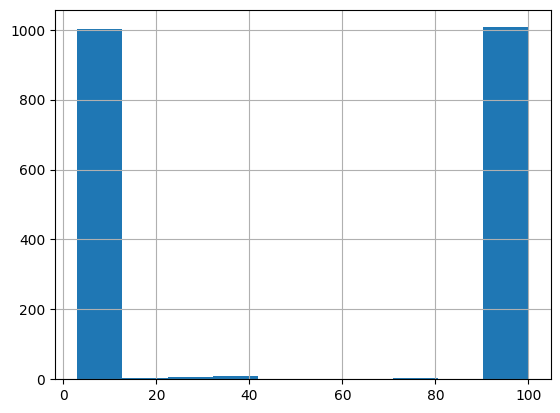

In [32]:
pd.Series(clipped_actions[clipped_actions[:,:,1] == 0][:,0]).hist()

In [41]:
model._last_obs = model.env.reset()

In [42]:
model._last_episode_starts

array([False, False, False, False, False, False, False, False])

# Env4 model: test initial action

In [1]:
import os
os.chdir('/data2/qingyuan/projects/zengcheng3')
import wandb

from stable_baselines3.common.vec_env import SubprocVecEnv, VecNormalize
from stable_baselines3.common.callbacks import CallbackList, CheckpointCallback

from reev_control.custom_ppo import CustomPPO
from reev_control.common.callbacks import (
    WandbCallbackWithVecNorm,
    AdvantageLoggingCallback,
)

from scripts.sb3_ppo_train_fe import *

# ======================================================
# Resume configuration
# ======================================================
RESUME_RUN_ID = "mh45qn8k"

MODEL_PATH = f"train_results/models/{RESUME_RUN_ID}/model.zip"
VECNORM_PATH = f"train_results/models/{RESUME_RUN_ID}/vec_env.pkl"

env_config.update({"reward_weights": [1, 5, 0.1, 0.05]})



os.environ["WANDB_DIR"] = "train_results"



# --------------------------------------------------
# Rebuild vectorized environment
# --------------------------------------------------
vec_env = SubprocVecEnv(
    [
        make_env(seed=200 + i, **env_config)
        for i in range(train_config["n_envs"])
    ]
)

# --------------------------------------------------
# Load VecNormalize (MUST be before model load)
# --------------------------------------------------
vec_env = VecNormalize.load(
    VECNORM_PATH,
    vec_env,
)

print(vec_env.training, vec_env.norm_reward)
vec_env.training = False
vec_env.norm_reward = False

# --------------------------------------------------
# Load model
# --------------------------------------------------
model = CustomPPO.load(
    MODEL_PATH,
    env=vec_env,
    device=train_config["device"],
)

print(f"[RESUME] model.num_timesteps = {model.num_timesteps:,}")




True False
[RESUME] model.num_timesteps = 4,177,664


In [ ]:
model.policy

In [1]:
from reev_control.common.feature_extractor import LSTMFeatureExtractor

ModuleNotFoundError: No module named 'reev_control'